<a href="https://colab.research.google.com/github/bajatsira/description-of-life-cycle-processes/blob/main/%D0%98%D0%A35%D0%A6_81%D0%91_%D0%A1%D0%B5%D0%BC%D0%B8%D0%BD%D0%B0%D1%808_%D0%A7%D1%83%D0%BF%D0%B0%D0%BD%D0%BE%D0%B2%D0%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install simpy

In [3]:
import simpy
import random
import matplotlib.pyplot as plt
import numpy as np

In [5]:
import simpy
import random
import matplotlib.pyplot as plt

%matplotlib inline

MAX_SERV_DURAT = 20 * 60     # максимальная длительность обслуживания 20 мин
MODE_SERV_DURAT = 7 * 60     # мода 7 мин
ARRIV_INTER = 3 * 60         # макс. интервал до появления нового покупателя
CONSUMER_TIME = 3600 * 10    # Время работы магазина (10 часов)

# ------------ Служебные параметры для статистики --------
myquelen = 0    # Текущая длина очереди
quelog = []     # журнал длины очереди
tservlog = []   # журнал пребывания в системе

# Класс - покупатель магазина - логический блок-процессор
class Client(object):
    def __init__(self, env, res, name='client'):
        self.name = name       # Имя покупателя, чтобы их различать
        self.env = env         # Среда моделирования
        self.res = res         # используемый при моделировании ресурс - касса

    def run(self):
        # ссылка на глобальные счетчики статистики
        global myquelen, quelog, tservlog

        # клиент пришел и встал в очередь
        timeq = self.env.now

        # Запрос свободной кассы
        with self.res.request() as req:
            # Нет свободной кассы? в очередь
            yield req

            # Свободная касса появилась!
            wait = self.env.now
            quelog.append((wait, len(self.res.queue)))

            # время обслуживания - случайное число, генерируем его
            serving_duration = int(random.triangular(30, MAX_SERV_DURAT, MODE_SERV_DURAT))

            # обслуживаемся в кассе!
            yield self.env.timeout(serving_duration)

            # Обслужились и освободили кассу. Запомним время пребывания
            tservlog.append((self.env.now, self.env.now - timeq))

In [6]:
def run_original_model(capacity_count):
    global quelog, tservlog

    # Очистка глобальных списков перед новым запуском
    quelog = []
    tservlog = []
    random.seed(13971)  # инициализация датчика случайных чисел из файла

    env = simpy.Environment()
    cashier = simpy.Resource(env, capacity=capacity_count)

    # Исходный источник покупателей
    def source_men(env):
        ind = 0
        while env.now < (CONSUMER_TIME - ARRIV_INTER):
            ind += 1
            yield env.timeout(random.randint(0, ARRIV_INTER))
            man = Client(env, cashier, name='клиент%s' % ind)
            env.process(man.run())

    env.process(source_men(env))
    env.run(until=12 * 60 * 60)

    # Возвращаем копии логов для сохранения результатов конкретного прогона
    return quelog.copy(), tservlog.copy()

# Запускаем config1, config2, config3 и config4(без терпения)
log_q1, log_t1 = run_original_model(capacity_count=6) # config1
log_q2, log_t2 = run_original_model(capacity_count=5) # config2
log_q3, log_t3 = run_original_model(capacity_count=4) # config3
log_q4_man, log_t4_man = run_original_model(capacity_count=3) # config4 (без учета терпения)

In [7]:
class ClientWithPatience(Client):
    def run(self):
        global myquelen, quelog, tservlog
        timeq = self.env.now

        with self.res.request() as req:
            # Определим время допустимого ожидания
            patience = random.randint(120, 300)

            # Нет свободной кассы? в очередь. Клиент ждет или выходит по таймауту
            results = yield (req | self.env.timeout(patience))

            wait = self.env.now
            quelog.append((wait, len(self.res.queue)))

            # Свободная касса появилась или терпение кончилось!
            if req in results:
                serving_duration = int(random.triangular(30, MAX_SERV_DURAT, MODE_SERV_DURAT))
                yield self.env.timeout(serving_duration)

            tservlog.append((self.env.now, self.env.now - timeq))

def run_patience_model(capacity_count):
    global quelog, tservlog
    quelog = []
    tservlog = []
    random.seed(13971)

    env = simpy.Environment()
    cashier = simpy.Resource(env, capacity=capacity_count)

    def source_men_patience(env):
        ind = 0
        while env.now < (CONSUMER_TIME - ARRIV_INTER):
            ind += 1
            yield env.timeout(random.randint(0, ARRIV_INTER))
            man = ClientWithPatience(env, cashier, name='клиент%s' % ind)
            env.process(man.run())

    env.process(source_men_patience(env))
    env.run(until=12 * 60 * 60)
    return quelog.copy(), tservlog.copy()

# Запускаем config4 с учетом допустимого ожидания (man1)
log_q4_man1, log_t4_man1 = run_patience_model(capacity_count=3)

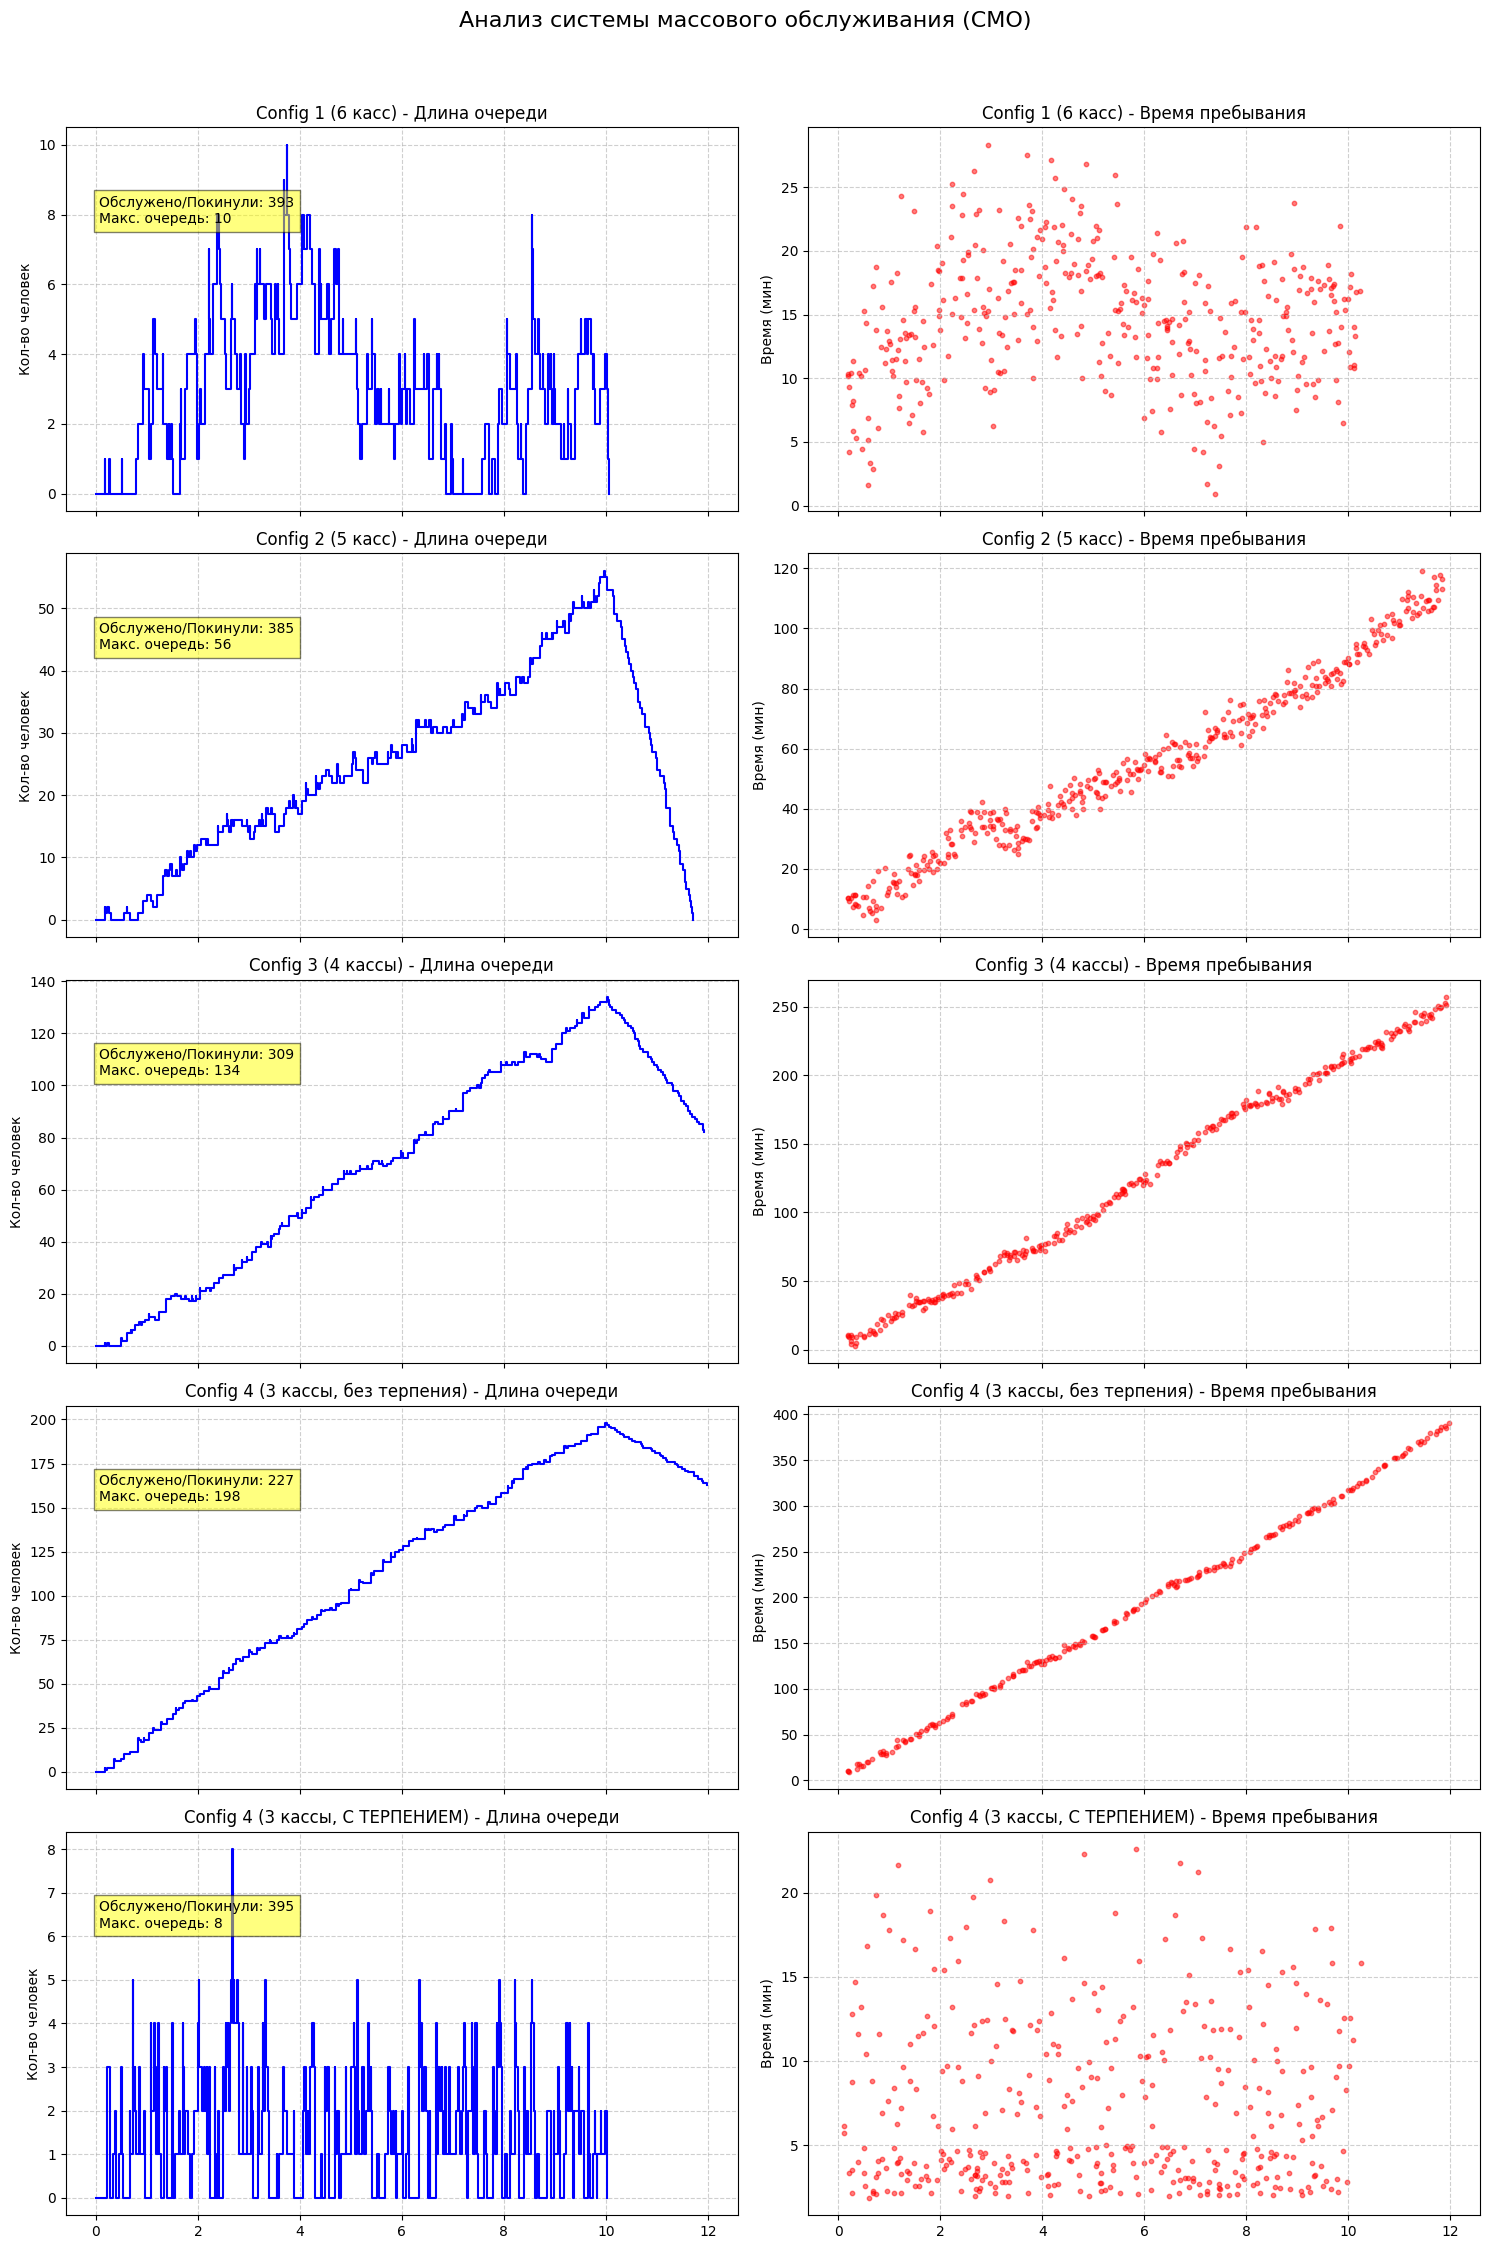


=== Сравнение Config 4 (3 кассы) ===
Доля клиентов с пребыванием <= 5 мин (БЕЗ ТЕРПЕНИЯ - man): 0.00%
Доля клиентов с пребыванием <= 5 мин (С ТЕРПЕНИЕМ - man1): 51.90%


In [8]:
configs = [
    ("Config 1 (6 касс)", log_q1, log_t1),
    ("Config 2 (5 касс)", log_q2, log_t2),
    ("Config 3 (4 кассы)", log_q3, log_t3),
    ("Config 4 (3 кассы, без терпения)", log_q4_man, log_t4_man),
    ("Config 4 (3 кассы, С ТЕРПЕНИЕМ)", log_q4_man1, log_t4_man1)
]

fig, axes = plt.subplots(len(configs), 2, figsize=(15, 22), sharex=True)
fig.suptitle('Анализ системы массового обслуживания (СМО)', fontsize=16, y=1.02)

for idx, (name, q_log, t_log) in enumerate(configs):
    # Данные очереди
    if q_log:
        q_times, q_lens = zip(*q_log)
        q_times_hours = [t / 3600 for t in q_times]
        max_queue = max(q_lens)
    else:
        q_times_hours, q_lens, max_queue = [], [], 0

    # Данные пребывания
    if t_log:
        t_times, durations = zip(*t_log)
        t_times_hours = [t / 3600 for t in t_times]
        durations_mins = [d / 60 for d in durations]
        total_served = len(t_log)
    else:
        t_times_hours, durations_mins, total_served = [], [], 0

    # --- График 1: Длина очереди ---
    axes[idx, 0].step(q_times_hours, q_lens, where='post', color='b')
    axes[idx, 0].set_title(f"{name} - Длина очереди")
    axes[idx, 0].set_ylabel("Кол-во человек")
    axes[idx, 0].grid(True, linestyle='--', alpha=0.6)

    # Текст на график
    info_text = f"Обслужено/Покинули: {total_served}\nМакс. очередь: {max_queue}"
    axes[idx, 0].text(0.05, 0.75, info_text, transform=axes[idx, 0].transAxes,
                      bbox=dict(facecolor='yellow', alpha=0.5))

    # --- График 2: Время пребывания ---
    axes[idx, 1].scatter(t_times_hours, durations_mins, color='r', s=10, alpha=0.5)
    axes[idx, 1].set_title(f"{name} - Время пребывания")
    axes[idx, 1].set_ylabel("Время (мин)")
    axes[idx, 1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# --- ЗАДАНИЕ 2: Расчет доли клиентов (<= 5 мин) ---
def get_share_under_5(t_log):
    if not t_log: return 0
    under_5 = sum(1 for _, duration in t_log if duration <= 300)
    return (under_5 / len(t_log)) * 100

share_man = get_share_under_5(log_t4_man)
share_man1 = get_share_under_5(log_t4_man1)

print("\n=== Сравнение Config 4 (3 кассы) ===")
print(f"Доля клиентов с пребыванием <= 5 мин (БЕЗ ТЕРПЕНИЯ - man): {share_man:.2f}%")
print(f"Доля клиентов с пребыванием <= 5 мин (С ТЕРПЕНИЕМ - man1): {share_man1:.2f}%")